# Exercises - Forward Rates

#### Notation Commands

$$\newcommand{\Black}{\mathcal{B}}
\newcommand{\Blackcall}{\Black_{\mathrm{call}}}
\newcommand{\Blackput}{\Black_{\mathrm{put}}}
\newcommand{\EcondS}{\hat{S}_{\mathrm{conditional}}}
\newcommand{\Efwd}{\mathbb{E}^{T}}
\newcommand{\Ern}{\mathbb{E}^{\mathbb{Q}}}
\newcommand{\Tfwd}{T_{\mathrm{fwd}}}
\newcommand{\Tunder}{T_{\mathrm{bond}}}
\newcommand{\accint}{A}
\newcommand{\carry}{\widetilde{\cpn}}
\newcommand{\cashflow}{C}
\newcommand{\convert}{\phi}
\newcommand{\cpn}{c}
\newcommand{\ctd}{\mathrm{CTD}}
\newcommand{\disc}{Z}
\newcommand{\done}{d_{1}}
\newcommand{\dt}{\Delta t}
\newcommand{\dtwo}{d_{2}}
\newcommand{\flatvol}{\sigma_{\mathrm{flat}}}
\newcommand{\flatvolT}{\sigma_{\mathrm{flat},T}}
\newcommand{\float}{\mathrm{flt}}
\newcommand{\freq}{m}
\newcommand{\futprice}{\mathcal{F}(t,T)}
\newcommand{\futpriceDT}{\mathcal{F}(t+h,T)}
\newcommand{\futpriceT}{\mathcal{F}(T,T)}
\newcommand{\futrate}{\mathscr{f}}
\newcommand{\fwdprice}{F(t,T)}
\newcommand{\fwdpriceDT}{F(t+h,T)}
\newcommand{\fwdpriceT}{F(T,T)}
\newcommand{\fwdrate}{f}
\newcommand{\fwdvol}{\sigma_{\mathrm{fwd}}}
\newcommand{\fwdvolTi}{\sigma_{\mathrm{fwd},T_i}}
\newcommand{\grossbasis}{B}
\newcommand{\hedge}{\Delta}
\newcommand{\ivol}{\sigma_{\mathrm{imp}}}
\newcommand{\logprice}{p}
\newcommand{\logyield}{y}
\newcommand{\mat}{(n)}
\newcommand{\nargcond}{d_{1}}
\newcommand{\nargexer}{d_{2}}
\newcommand{\netbasis}{\tilde{\grossbasis}}
\newcommand{\normcdf}{\mathcal{N}}
\newcommand{\notional}{K}
\newcommand{\pfwd}{P_{\mathrm{fwd}}}
\newcommand{\pnl}{\Pi}
\newcommand{\price}{P}
\newcommand{\probexer}{\hat{\mathcal{P}}_{\mathrm{exercise}}}
\newcommand{\pvstrike}{K^*}
\newcommand{\refrate}{r^{\mathrm{ref}}}
\newcommand{\rrepo}{r^{\mathrm{repo}}}
\newcommand{\spotrate}{r}
\newcommand{\spread}{s}
\newcommand{\strike}{K}
\newcommand{\swap}{\mathrm{sw}}
\newcommand{\swaprate}{\cpn_{\swap}}
\newcommand{\tbond}{\mathrm{fix}}
\newcommand{\ttm}{\tau}
\newcommand{\value}{V}
\newcommand{\vega}{\nu}
\newcommand{\years}{\tau}
\newcommand{\yearsACT}{\tau_{\mathrm{act/360}}}
\newcommand{\yield}{Y}$$

This exercise builds on the bootstrapped spot curve to calculate forward rates.

### Data

Use the bootstrapped spot curve from the data file:
`data/treasury_quotes_2025-11-28.xlsx`, sheet `selected quotes`

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
SHEET_NAME = 'treasury_quotes_2025-11-28.xlsx'

***

### 1.1. Bootstrap the Spot Curve

Using the selected quotes (approximately 6-month intervals), bootstrap the spot curve.

Report for maturity T=5:
* The discount factor
* The semiannually-compounded spot rate
* The continuously-compounded spot rate

Round to 4 decimal places.

In [8]:
selected_quotes = pd.read_excel(SHEET_NAME, sheet_name='selected quotes')
MATURITY = 5
PAR = 100.0
COUPON_FREQ = 2  # Semiannual coupons

In [9]:
spot_rates = {}
discount_factors = {}

selected_quotes = selected_quotes.copy()
selected_quotes['ttm'] = (
    np.round(selected_quotes['ttm'] * COUPON_FREQ) / COUPON_FREQ
)
selected_quotes = selected_quotes.sort_values('ttm')

for index, row in selected_quotes.iterrows():
    T = row['ttm']
    price = row['price']
    coupon_rate = row['cpn rate']  / 100.0
    coupon_amt = PAR * coupon_rate / COUPON_FREQ
    num_periods = int(round(T*COUPON_FREQ))

    sum_discounted_coupons = 0.0
    for i in range(1, num_periods):
        t_i = i / COUPON_FREQ
        sum_discounted_coupons += coupon_amt * discount_factors[t_i]
    
    z_t = (price - sum_discounted_coupons) / (PAR + coupon_amt)
    discount_factors[T] = z_t

    semiannual_spot = 2 * ( (1 / z_t)**(1 / (2 * T)) - 1 )
    spot_rates[T] = semiannual_spot

#Results for T = 5
T_target = 5.0
df_5 = discount_factors[T_target]
semi_spot_5 = spot_rates[T_target]
# Continuous rate: r_c = ln(1 + z/2) * 2 or simply -ln(Z(T))/T
cont_spot_5 = -np.log(df_5) / T_target

print(f"Results for T= {T_target}:")
print(f"Discount Factor: {df_5:.4f}")
print(f"Semiannual Spot Rate: {semi_spot_5:.4f}")
print(f"Continuous Spot Rate: {cont_spot_5:.4f}")

Results for T= 5.0:
Discount Factor: 0.8365
Semiannual Spot Rate: 0.0360
Continuous Spot Rate: 0.0357


### 1.2. Forward Discount Factors

Using the spot curve, calculate the 6-month forward discount factors:

$$F(0, T, T+0.5) = \frac{Z(0, T+0.5)}{Z(0, T)}$$

Report a table with columns:
* `T` (starting maturity)
* `forward discount` 
* `forward rate (semi-annual)`
* `forward rate (continuous)`

For T=5 to T=5.5, report all three values rounded to 4 decimal places.

In [10]:
forward_data = []
maturities = sorted(discount_factors.keys())

for i in range(len(maturities) - 1):
    T = maturities[i]
    T_next = maturities[i+1]
    
    #Interval is exactly 0.5 years (6 months)
    if np.isclose(T_next - T, 0.5):
        z_t = discount_factors[T]
        z_next = discount_factors[T_next]
        
        #Forward Discount Factor F(0, T, T+0.5)
        f_discount = z_next / z_t
        
        #Forward Rate (Semi-annual)
            #Formula: F = 1 / (1 + f_s/2) => f_s = 2 * (1/F - 1)
        f_semi = 2 * ( (1 / f_discount) - 1 )
        
        #Forward Rate (Continuous)
            #Formula: F = exp(-f_c * 0.5) => f_c = -ln(F) / 0.5
        f_cont = -np.log(f_discount) / 0.5
        
        forward_data.append({
            'T': T,
            'Forward discount': f_discount,
            'Forward rate (semi-annual)': f_semi,
            'Forward rate (continuous)': f_cont
        })

#Results
df_forwards = pd.DataFrame(forward_data)

# Display specific rows (T=5 and T=5.5)
display(df_forwards[(df_forwards['T'] == 5.0)].round(4))


,T,Forward discount,Forward rate (semi-annual),Forward rate (continuous)
9,5.0,0.9787,0.0435,0.0431


### 1.3. Forward Curve Analysis

1. Plot the spot rate curve and the 6-month forward rate curve on the same axes.

2. For which maturity interval $(T_1, T_2)$ is the forward rate highest?

3. At maturities where the forward rate is above the spot rate, what does this imply about the slope of the spot curve?

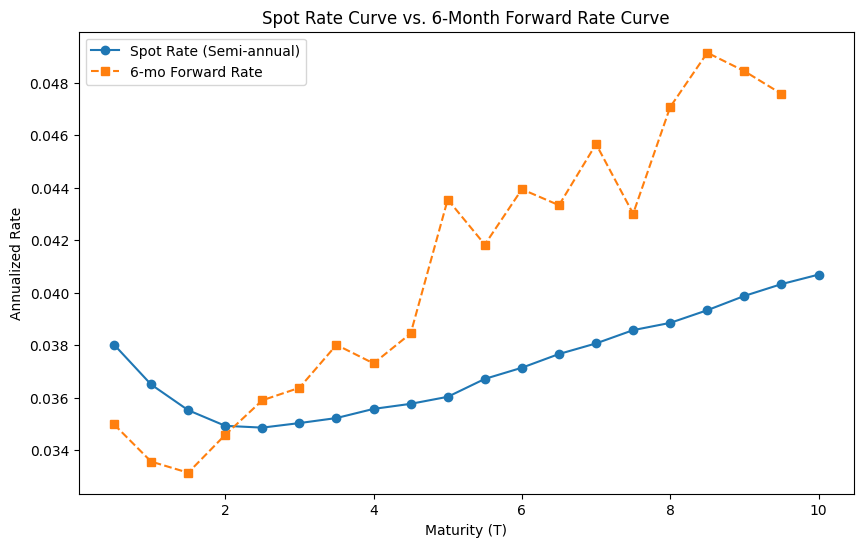

In [11]:
#Plot
spot_df = pd.DataFrame(list(spot_rates.items()), columns=['T', 'spot_rate'])

plt.figure(figsize=(10, 6))
plt.plot(spot_df['T'], spot_df['spot_rate'], marker='o', label='Spot Rate (Semi-annual)')
plt.plot(df_forwards['T'], df_forwards['Forward rate (semi-annual)'], marker='s', linestyle='--', label='6-mo Forward Rate')
plt.title('Spot Rate Curve vs. 6-Month Forward Rate Curve')
plt.xlabel('Maturity (T)')
plt.ylabel('Annualized Rate')
plt.legend()

In [12]:
#Highest Forward Rate
max_f_row = df_forwards.loc[df_forwards['Forward rate (semi-annual)'].idxmax()]
print(f"The highest forward rate is {max_f_row['Forward rate (semi-annual)']:.4f} for the interval (T1: {max_f_row['T']}, T2: {max_f_row['T'] + 0.5}).")

The highest forward rate is 0.0491 for the interval (T1: 8.5, T2: 9.0).


When the forward rate is higher than the spot average, this indicates that the marginal return for the next period is greater than the current average. This pulls the average up, resulting in the upward-sloping spot curve that we can see above. Thus, for the spot curve to rise, the forward curve must stay positioned above it in ordeer to "pull" it up.

***